# Project card

**The paper:** 
>Volatility of Mutator Phenotypes at Single
Cell Resolution

**The data object:**
>Novel mutation count per cell division for all lineages

**The random variable chosen:**

>Mutation count

**What the paper does:**
>Models mutation rate in mutator phenotypes of yeast. It counts the number of mutations in each cell division and fits it to a 2-Poisson model.

**The generative model proposed:**
2-poisson model
https://link.springer.com/rwe/10.1007/978-0-387-39940-9_920

**Parameters and assumptions:**
total count of cells = N
**The forward simulation:**

Monte-Carlo simulation
Grid search to find paramters for 2 poisson
**The parameterization/fitting:**

**What/if the model adds to the paper:**

**Model limitations/how it breaks:**

***

### Libraries 

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math

### Functions

In [ ]:
def mean(counts):
    """The mean of a list of counts."""
    return sum(counts) / len(counts)

def std_dev(counts):
    """The standard deviation of a list of counts."""
    m = mean(counts)
    total = 0.0
    for x in counts:
        total = total + (x - m) ** 2
    return math.sqrt(total / len(counts))

def factorial(x):
    """x! as a product, 0! = 1."""
    total = 1
    for k in range(1, x + 1):
        total = total * k
    return total

def poisson(x, theta):
    """p(x | theta) = theta^x e^(-theta) / x!  the probability of x counts in a cell at rate theta."""
    return theta ** x * math.exp(-theta) / factorial(x)

def likelihood(counts, theta):
    """L(theta) = p(x | theta) = the product over cells of p(x_i | theta)."""
    total = 1.0
    for x in counts:
        total = total * poisson(x, theta)
    return total


def nll(counts, theta):
    """NLL(theta) = - the sum over cells of ln p(x_i | theta)."""
    total = 0.0
    for x in counts:
        total = total - math.log(poisson(x, theta))
    return total


def position_of_min(values):
    """The index of the smallest entry: the position, not the value."""
    best = 0
    for j in range(len(values)):
        if values[j] < values[best]:
            best = j
    return best

### Data

# Read the files

In [39]:
df = pd.read_excel("data/mutation_counts.xlsx", header=0, skiprows=[1], index_col=0)
df = df.replace(r"^\s*$", np.nan, regex=True)
df = df.astype(float)

lineages = [list(df[column].dropna()) for column in df.columns]

print(df,"\n")
print("\n".join(str(lin) for lin in lineages))

           B    C    D     E   F*   G1   G2    H
Lineage                                         
3        0.0  3.0  2.0   2.0  3.0  1.0  NaN  7.0
4        2.0  7.0  2.0   3.0  7.0  1.0  NaN  0.0
5        0.0  6.0  0.0   1.0  1.0  0.0  7.0  2.0
6        3.0  0.0  3.0   6.0  3.0  0.0  6.0  0.0
7        2.0  0.0  0.0   0.0  2.0  3.0  0.0  4.0
8        4.0  2.0  0.0   0.0  NaN  6.0  5.0  3.0
9        1.0  3.0  1.0   0.0  NaN  4.0  0.0  4.0
10       3.0  4.0  1.0   8.0  0.0  5.0  NaN  1.0
11       4.0  4.0  4.0   0.0  5.0  3.0  NaN  4.0
12       NaN  6.0  5.0  10.0  2.0  5.0  NaN  1.0
13       NaN  5.0  3.0   NaN  3.0  4.0  NaN  1.0
14       NaN  1.0  0.0   NaN  1.0  NaN  NaN  3.0
15       NaN  0.0  9.0   NaN  NaN  NaN  NaN  NaN
16       NaN  NaN  4.0   NaN  NaN  NaN  NaN  NaN
17       NaN  NaN  2.0   NaN  NaN  NaN  NaN  NaN 

[0.0, 2.0, 0.0, 3.0, 2.0, 4.0, 1.0, 3.0, 4.0]
[3.0, 7.0, 6.0, 0.0, 0.0, 2.0, 3.0, 4.0, 4.0, 6.0, 5.0, 1.0, 0.0]
[2.0, 2.0, 0.0, 3.0, 0.0, 0.0, 1.0, 1.0, 4.0, 5.0, 3.

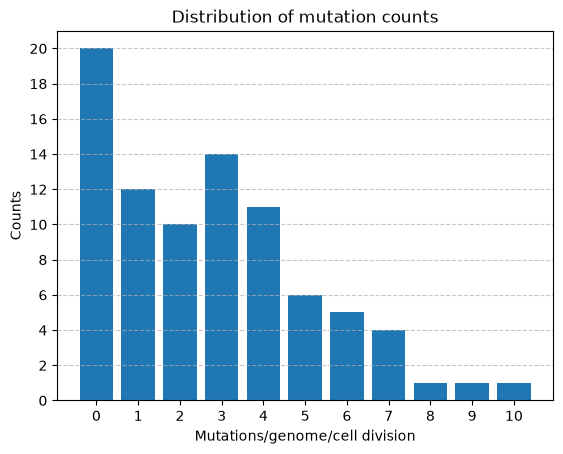

In [31]:

total_mutation_count = 0
N = 0 # Number of cell divisions
max_mutation_count = int(max([max(x) for x in lineages]))

# Get all the mutations counts observed in all cell divisions
mutation_counts = [0] * (max_mutation_count + 1)

for lineage in lineages:
    for mutation_count in lineage:
        count = int(mutation_count)
        total_mutation_count += mutation_count
        N += 1
        mutation_counts[count] += 1

mu = total_mutation_count / N

plt.bar(range((max_mutation_count)+1), mutation_counts)
plt.xlabel("Mutations/genome/cell division")
plt.ylabel("Counts")
plt.xticks(range(0,11));
plt.yticks(range(0,22,2));
plt.grid(axis='y', linestyle='--', alpha=0.7, zorder=0)
plt.title("Distribution of mutation counts")
plt.show()

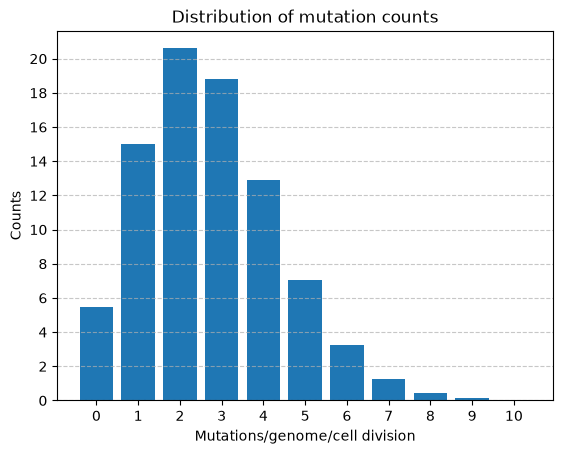

In [32]:

counts = range(int(max_mutation_count)+1)
y = [0] * len(counts)
for i in range(len(counts)):
    y[i] += poisson(counts[i], mu)

y = [x*N for x in y]
plt.bar(counts, y)
plt.xlabel("Mutations/genome/cell division")
plt.ylabel("Counts")
plt.xticks(range(0,11));
plt.yticks(range(0,22,2));
plt.grid(axis='y', linestyle='--', alpha=0.7, zorder=0)
plt.title("Distribution of mutation counts")
plt.show()

In [ ]:
# Negative Binomial

In [ ]:
# Baysian

In [ ]:
# AIC

In [ ]:
# 1-Poisson

In [ ]:
# 2-Poisson

In [ ]:
# 3-Poisson